# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import numpy as np

from impl.problem import mr_set
from impl.utils.visualization import visualize_archived_distinct_solutions, visualize_distinct_solution_over_simulations

pygame 2.1.2 (SDL 2.0.16, Python 3.7.17)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Prepare data

In [34]:
solution_files = {
    "ccea": [
        "1727209526466", "1727240994672", "1727266901005", "1727295192682", "1727323277274",
        "1727350900214", "1727380354661", "1727411465615", "1727439594179", "1727469833556",
    ],
    "ga": [
        "1727222567297", "1727250570553", "1727277786075", "1727305247085", "1727332417742",
        "1727360236396", "1727391457944", "1727421077088", "1727450998141", "1727480862318",
    ],
    "rs": [
        "1727232907851", "1727259420090", "1727286578674", "1727314239612", "1727341179646",
        "1727369189391", "1727401251184", "1727430452614", "1727460765043", "1727490053161",
    ],
}
checkpoints = {
    "ccea": [
        ["1727201519649.pickle", "1727209525799.pickle"],
        ["1727235598273.pickle", "1727240994238.pickle"],
        ["1727261716665.pickle", "1727266900474.pickle"],
        ["1727288292889.pickle", "1727295192277.pickle"],
        ["1727316247139.pickle", "1727323276634.pickle"],
        ["1727343419222.pickle", "1727350899632.pickle"],
        ["1727373922607.pickle", "1727380353945.pickle"],
        ["1727403610820.pickle", "1727411465040.pickle"],
        ["1727432664046.pickle", "1727439593383.pickle"],
        ["1727462943800.pickle", "1727469832790.pickle"],
    ],
    "ga": [
        ["1727209911905.pickle", "1727222566366.pickle"],
        ["1727241404211.pickle", "1727250570021.pickle"],
        ["1727267613418.pickle", "1727277785562.pickle"],
        ["1727295908578.pickle", "1727305246414.pickle"],
        ["1727323806097.pickle", "1727332417270.pickle"],
        ["1727351350346.pickle", "1727360235858.pickle"],
        ["1727380896561.pickle", "1727391457305.pickle"],
        ["1727412055217.pickle", "1727421076474.pickle"],
        ["1727440319781.pickle", "1727450997411.pickle"],
        ["1727470376451.pickle", "1727480861750.pickle"],
    ],
    "rs": [
        ["1727223364731.pickle", "1727232907448.pickle"],
        ["1727251274947.pickle", "1727259419608.pickle"],
        ["1727278306501.pickle", "1727286578130.pickle"],
        ["1727306232310.pickle", "1727314239208.pickle"],
        ["1727333077420.pickle", "1727341179299.pickle"],
        ["1727360732518.pickle", "1727369188866.pickle"],
        ["1727392085249.pickle", "1727401250811.pickle"],
        ["1727421643803.pickle", "1727430452209.pickle"],
        ["1727451559666.pickle", "1727460764631.pickle"],
        ["1727481385453.pickle", "1727490052651.pickle"],
    ],
}

# Plots for RQ1

In [3]:
import pickle
from scipy.spatial.distance import pdist

dists = []
fitnesses = []
for name, times in solution_files.items():
    for time in times:
        path = f"out/solutions/solutions-{name}-{time}.pickle"
        with open(path, "rb") as f:
            solutions = pickle.load(f)
        fitnesses += [sol.fitness.values[0] for sol in solutions]
        follow_ups = []
        for scenario, perturbation in solutions:
            perturbation.perturb(scenario)
            follow_ups.append(scenario)
        dist = pdist(np.array(follow_ups, dtype=object).reshape((len(follow_ups), -1)), lambda x, y: x[0].dist(y[0]))
        dists = np.concatenate((dists, dist))
print(np.quantile(fitnesses, [0.5, 0.7, 0.9]).round(1))
print(np.quantile(dists, [0.1, 0.3, 0.5]).round(1))

[0.3 0.8 1.5]
[1.1 1.5 1.7]


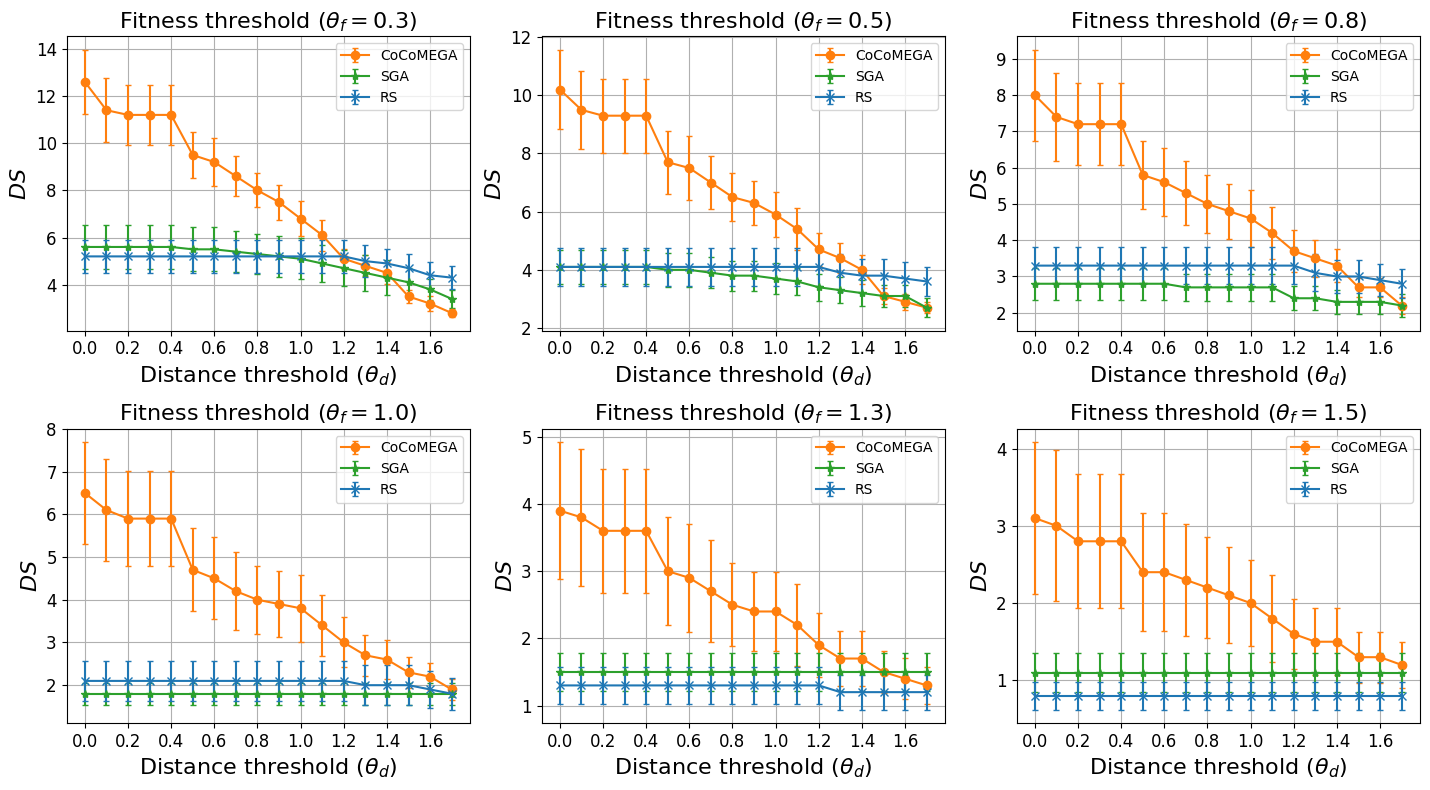

In [8]:
solution_stats = visualize_archived_distinct_solutions(
    {name: [f"out/solutions/solutions-{name}-{time}.pickle" for time in times]
     for name, times in solution_files.items()},
    fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
    distance_thresholds=np.arange(0, 1.71, 0.1).round(1),
    box=False, show=True)

# Tables for RQ1

In [13]:
verbose_map = {
    "ccea": "\emph{\gls{ours}}",
    "ga": "\emph{\gls{sga}}",
    "rs": "\emph{\gls{rs}}",
}
table_str = ("\\toprule\n"
             "\\multirow{2}{2em}{\\boldmath{\\(\\theta_d\\)}}&\\multirow{2}{*}{\\textbf{Method}}&\\multicolumn{6}{c}{\\textbf{Average \\emph{\\gls{mrc}}\\boldmath{\\(\\pm CI_{0.95}\\)} (Average \\emph{\\gls{cmr}}\\boldmath{\\(\\pm CI_{0.95}\\)})}}\\\\\n"
             "\\cmidrule{3-8}\n"
             "&&\\(\\theta_f=0.3\\)&\\(\\theta_f=0.5\\)&\\(\\theta_f=0.8\\)&\\(\\theta_f=1.0\\)&\\(\\theta_f=1.3\\)&\\(\\theta_f=1.5\\)\\\\\n")
for distance_threshold in (0.0, 1.0, 1.7):
    table_str += f"\\midrule\n\\multirow{{6}}{{2em}}{{\\(\\theta_d={distance_threshold}\\)}}"
    for name, df in solution_stats.items():
        table_str += f"&{verbose_map[name]}"
        df = (df.groupby("distance_threshold").get_group(distance_threshold)
              .groupby("fitness_threshold").agg(list)
              .sort_values("fitness_threshold", ascending=True))
        for index, row in df.iterrows():
            values = np.array(row["violated_mr_num"]) * 100 / len(mr_set.mrs)
            ci = 0.95 * np.std(values) / np.sqrt(len(values))
            table_str += f"&\\({np.mean(values):.1f}\\pm{ci:.1f}\\)"
            values = row["distinct_mr_num"]
            ci = 0.95 * np.std(values) / np.sqrt(len(values))
            table_str += f" (\\({np.mean(values):.1f}\\pm{ci:.1f}\\))"
        table_str += "\\\\\n"
table_str += "\\bottomrule\n"
print(table_str)

\toprule
\multirow{2}{2em}{\boldmath{\(\theta_d\)}}&\multirow{2}{*}{\textbf{Method}}&\multicolumn{6}{c}{\textbf{Average \emph{\gls{mrc}}\boldmath{\(\pm CI_{0.95}\)} (Average \emph{\gls{cmr}}\boldmath{\(\pm CI_{0.95}\)})}}\\
\cmidrule{3-8}
&&\(\theta_f=0.3\)&\(\theta_f=0.5\)&\(\theta_f=0.8\)&\(\theta_f=1.0\)&\(\theta_f=1.3\)&\(\theta_f=1.5\)\\
\midrule
\multirow{6}{2em}{\(\theta_d=0.0\)}&\emph{\gls{ours}}&\(100.0\pm0.0\) (\(3.0\pm0.3\))&\(98.0\pm1.8\) (\(2.6\pm0.3\))&\(90.0\pm7.2\) (\(2.1\pm0.3\))&\(78.0\pm10.9\) (\(1.8\pm0.4\))&\(66.0\pm12.3\) (\(1.3\pm0.3\))&\(56.0\pm13.1\) (\(1.0\pm0.3\))\\
&\emph{\gls{sga}}&\(88.0\pm7.2\) (\(4.2\pm0.5\))&\(84.0\pm8.8\) (\(3.4\pm0.5\))&\(82.0\pm8.7\) (\(2.6\pm0.4\))&\(66.0\pm10.8\) (\(1.8\pm0.3\))&\(56.0\pm11.7\) (\(1.5\pm0.3\))&\(40.0\pm11.4\) (\(1.1\pm0.2\))\\
&\emph{\gls{rs}}&\(92.0\pm7.2\) (\(1.0\pm0.0\))&\(90.0\pm9.0\) (\(0.9\pm0.1\))&\(90.0\pm9.0\) (\(0.9\pm0.1\))&\(64.0\pm13.4\) (\(0.8\pm0.1\))&\(48.0\pm12.9\) (\(0.8\pm0.1\))&\(22.0\pm8.3\) (\

# Plots for RQ2

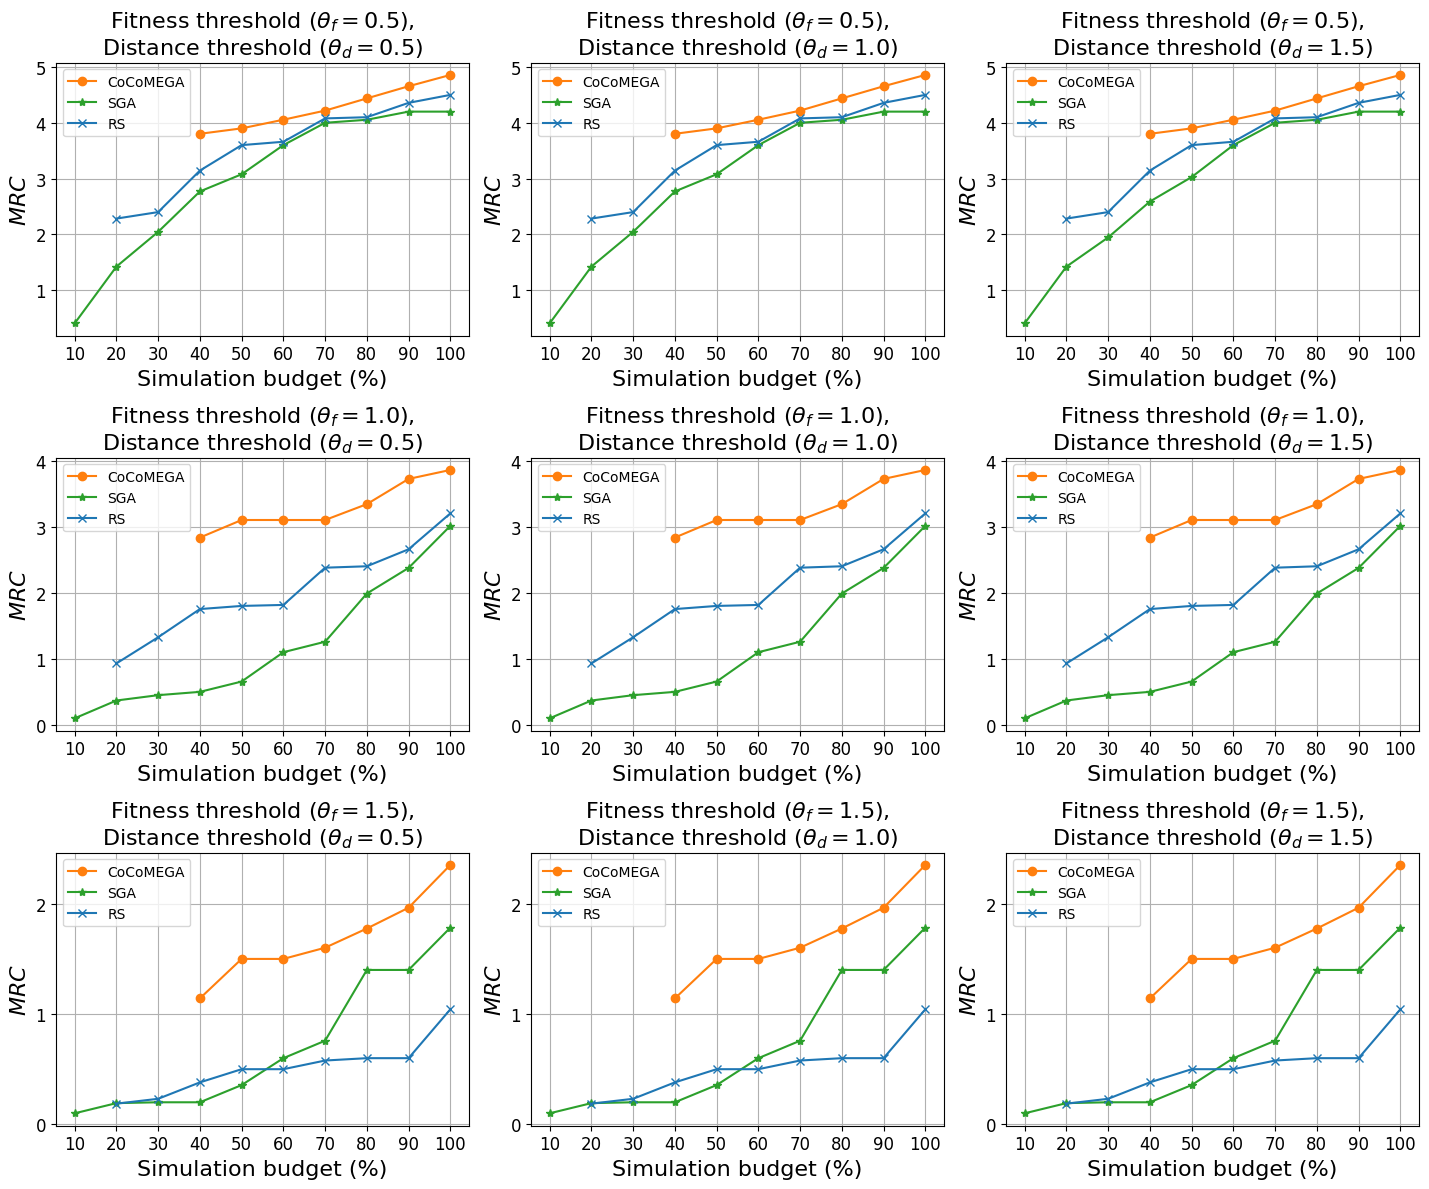

In [36]:
visualize_distinct_solution_over_simulations("out/checkpoints", checkpoints,
                                             fitness_thresholds=[0.5, 1.0, 1.5],
                                             distance_thresholds=[0.5, 1.0, 1.5],
                                             max_sim_num=200, mr=True, show=True)